# FTP-IDS — Model Evaluation

Evaluate the ML detector (Isolation Forest) on a labeled dataset 
of 109 sessions. The model is trained on normal sessions only, 
then scored against all sessions to measure detection performance.

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (9, 4)

from ftp_ids.parsers.vsftpd_parser import VsftpdParser
from ftp_ids.core.session_builder import build_sessions
from ftp_ids.core.feature_extractor import FeatureExtractor, FEATURE_NAMES
from ftp_ids.core.detector import Detector
from ftp_ids.core.rule_engine import RuleEngine

LOG_PATH = '../data/samples/vsftpd.log'
MODEL_PATH = "/tmp/eval_model.pkl"

## 1. Parse and label sessions

parsing the anonymized log file to extract sessions and features.
Each session is labeled as "normal" if it authenticated as the deploy 
user, or "attack" if not.

In [159]:
parser = VsftpdParser()
events = []
with open(LOG_PATH, "r", errors="replace") as f:
    for line in f:
        e = parser.parse_line(line)
        if e:
            events.append(e)

sessions = build_sessions(events)
fe = FeatureExtractor()

rows = []
for s in sessions:
    feats = fe.extract(s)
    user = s.get("user") or ""
    is_normal = ("deploy_user" in user) and feats["is_auth"] == 1
    rows.append({
        "src_ip": s["src_ip"],
        "user": user,
        "start_time": s["start_time"],
        "end_type": s["end_type"],
        **feats,
        "label": "normal" if is_normal else "attack",
    })

df = pd.DataFrame(rows)
y_true = df["label"].values

print(f"Total sessions: {len(df)}")
print(f"\nClass balance:")
print(df["label"].value_counts())

Total sessions: 109

Class balance:
label
normal    98
attack    11
Name: count, dtype: int64


## 2. Train the model

The model trains on all sessions. Isolation Forest uses 
the contamination parameter (0.05) to expect a small proportion 
of anomalies in the training data. I used 5% to reflect my real 
dataset anomaly count.

In [160]:
X_train = df[FEATURE_NAMES]

print(f"Training on {len(X_train)} sessions (matching production behavior)")
print(f"Will evaluate on all {len(df)} sessions")

detector = Detector(model_path=MODEL_PATH, contamination=0.05)
detector.train_on_features(X_train)

Training on 109 sessions (matching production behavior)
Will evaluate on all 109 sessions
Model retrained and saved to /tmp/eval_model.pkl


## 3. Score all sessions

Each session gets a score from 0.0 to 1.0. A low score means the 
session looks normal. A high score means it looks suspicious.

In [161]:
scores = []
X_all = df[FEATURE_NAMES]

for _, row in X_all.iterrows():
    row_df = pd.DataFrame([row])
    raw = -detector.pipeline.decision_function(row_df)[0]
    norm = detector.score_scaler.transform([[raw]])[0][0]
    scores.append(float(norm))

df["score"] = scores

print("Score statistics by label:")
print(df.groupby("label")["score"].describe().round(3))

Score statistics by label:
        count   mean    std    min   25%    50%    75%   max
label                                                       
attack   11.0  0.769  0.129  0.577  0.65  0.803  0.842  0.99
normal   98.0  0.253  0.212  0.000  0.08  0.186  0.388  1.00


## 4. Score distribution

This chart shows how normal and attack sessions are scored. If the 
two groups separate clearly, the model can tell them apart.

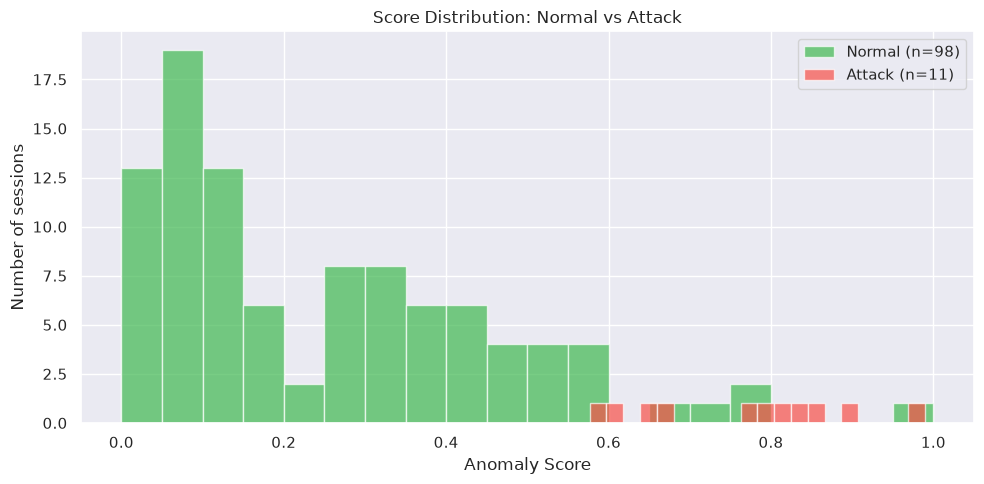

In [162]:
fig, ax = plt.subplots(figsize=(10, 5))

normal_scores = df[df["label"] == "normal"]["score"]
attack_scores = df[df["label"] == "attack"]["score"]

ax.hist(normal_scores, bins=20, alpha=0.7, label=f"Normal (n={len(normal_scores)})", color="#3fb950")
ax.hist(attack_scores, bins=20, alpha=0.7, label=f"Attack (n={len(attack_scores)})", color="#f85149")

ax.set_xlabel("Anomaly Score")
ax.set_ylabel("Number of sessions")
ax.set_title("Score Distribution: Normal vs Attack")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Threshold sweep

I tested every threshold from 0.05 to 0.95 to find which one gives 
the best F1 score. The best threshold is the one that catches the 
most attacks without flagging too many normal sessions.

In [163]:
thresholds = np.arange(0.05, 1.0, 0.05)
results = []

for t in thresholds:
    y_pred = ["attack" if s >= t else "normal" for s in df["score"]]
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, pos_label="attack", average="binary")
    results.append({"threshold": round(t, 2), "precision": round(p, 3), "recall": round(r, 3), "f1": round(f, 3)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best = results_df.loc[results_df["f1"].idxmax()]
print(f"\nBest threshold: {best['threshold']} (F1 = {best['f1']})")

 threshold  precision  recall    f1
      0.05      0.115   1.000 0.206
      0.10      0.143   1.000 0.250
      0.15      0.172   1.000 0.293
      0.20      0.190   1.000 0.319
      0.25      0.196   1.000 0.328
      0.30      0.229   1.000 0.373
      0.35      0.275   1.000 0.431
      0.40      0.324   1.000 0.489
      0.45      0.393   1.000 0.564
      0.50      0.458   1.000 0.629
      0.55      0.550   1.000 0.710
      0.60      0.667   0.909 0.769
      0.65      0.615   0.727 0.667
      0.70      0.636   0.636 0.636
      0.75      0.700   0.636 0.667
      0.80      0.857   0.545 0.667
      0.85      0.667   0.182 0.286
      0.90      0.500   0.091 0.154
      0.95      0.500   0.091 0.154

Best threshold: 0.6 (F1 = 0.769)


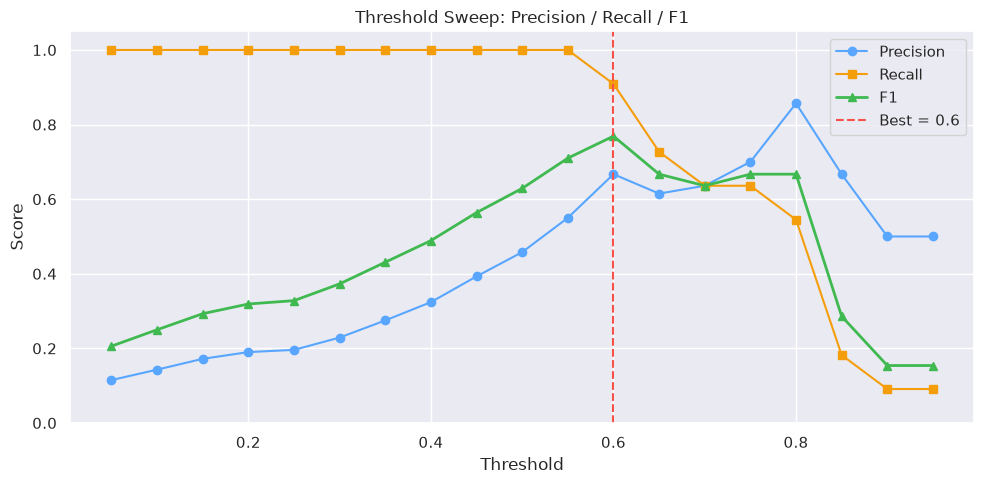

In [164]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df["threshold"], results_df["precision"], "o-", label="Precision", color="#58a6ff")
ax.plot(results_df["threshold"], results_df["recall"], "s-", label="Recall", color="#f59e0b")
ax.plot(results_df["threshold"], results_df["f1"], "^-", label="F1", color="#3fb950", linewidth=2)

ax.axvline(x=best["threshold"], color="#f85149", linestyle="--", label=f"Best = {best['threshold']}")

ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Sweep: Precision / Recall / F1")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 6. Confusion matrix

This shows how many sessions the model got right and wrong at the 
best threshold. True Normal/Attack = what the session really is. 
Pred Normal/Attack = what the model predicted.

Threshold: 0.6

              precision    recall  f1-score   support

      attack       0.67      0.91      0.77        11
      normal       0.99      0.95      0.97        98

    accuracy                           0.94       109
   macro avg       0.83      0.93      0.87       109
weighted avg       0.96      0.94      0.95       109



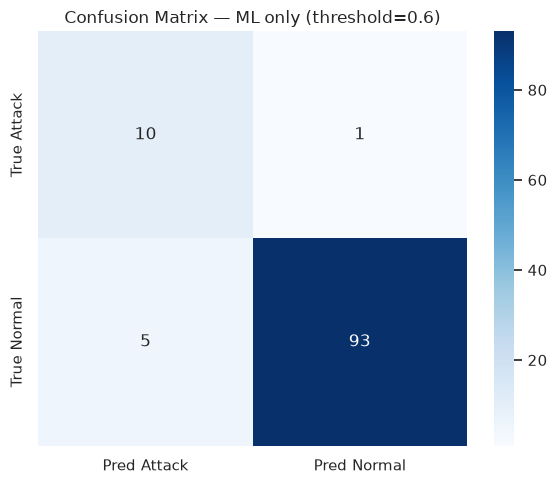

In [165]:
best_t = best["threshold"]
y_pred_best = ["attack" if s >= best_t else "normal" for s in df["score"]]

print(f"Threshold: {best_t}\n")

print(classification_report(
    y_true, 
    y_pred_best, 
    labels=["attack", "normal"],
    target_names=["attack", "normal"]
))

cm = confusion_matrix(y_true, y_pred_best, labels=["attack", "normal"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Attack", "Pred Normal"],
            yticklabels=["True Attack", "True Normal"], ax=ax)
ax.set_title(f"Confusion Matrix — ML only (threshold={best_t})")
plt.tight_layout()
plt.show()

## 7. Summary

In [166]:
print(f"Dataset:         {len(df)} sessions ({(df.label=='normal').sum()} normal, {(df.label=='attack').sum()} attack)")
print(f"Training:        {len(X_train)} sessions (all, contamination=0.05)")
print(f"Best threshold:  {best_t}")
print()
print("ML detector performance:")
print(classification_report(y_true, y_pred_best, labels=["normal", "attack"], target_names=["normal", "attack"]))

Dataset:         109 sessions (98 normal, 11 attack)
Training:        109 sessions (all, contamination=0.05)
Best threshold:  0.6

ML detector performance:
              precision    recall  f1-score   support

      normal       0.99      0.95      0.97        98
      attack       0.67      0.91      0.77        11

    accuracy                           0.94       109
   macro avg       0.83      0.93      0.87       109
weighted avg       0.96      0.94      0.95       109

